In [129]:
'''EXPLORATORY DATA ANALYSIS
   Renewable Energy Production Dataset
   Capstone Project, (EDA & Visualization)'''

import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

os.makedirs('../Visualisations/EDA', exist_ok=True)
warnings.filterwarnings('ignore')

# Set style for professional look
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

In [130]:
# 1. DATA LOADING

df = pd.read_csv("../Data/Modified Dataset/Dataset_with_Weather_features.csv")
print(f"\n Dataset loaded: {len(df):,} rows, {len(df.columns)} columns")

# Display first 5 rows
print("\n First 5 rows:")
df.head()


 Dataset loaded: 51,862 rows, 14 columns

 First 5 rows:


,Date,Start_Hour,End_Hour,Source,Day_of_Year,Day_Name,Month_Name,Season,Production,Temperature_C,Humidity_Percent,Precipitation_mm,WindSpeed_kmh,Rainfall_Flag
0,2025-11-30,21,22,Wind,334,Sunday,November,Fall,5281,11.8,72,0.0,5.9,No
1,2025-11-30,18,19,Wind,334,Sunday,November,Fall,3824,13.5,67,0.0,7.2,No
2,2025-11-30,16,17,Wind,334,Sunday,November,Fall,3824,17.3,50,0.0,5.1,No
3,2025-11-30,23,0,Wind,334,Sunday,November,Fall,6120,10.4,69,0.0,5.4,No
4,2025-11-30,6,7,Wind,334,Sunday,November,Fall,4387,8.2,62,0.0,1.6,No


In [131]:
# 2. DATA OVERVIEW

# Data types and info
print("\n Data Types:")
df.info()

# Summary statistics
print("\n Summary Statistics:")
df.describe(include='all')


 Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51862 entries, 0 to 51861
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              51862 non-null  object 
 1   Start_Hour        51862 non-null  int64  
 2   End_Hour          51862 non-null  int64  
 3   Source            51862 non-null  object 
 4   Day_of_Year       51862 non-null  int64  
 5   Day_Name          51862 non-null  object 
 6   Month_Name        51862 non-null  object 
 7   Season            51862 non-null  object 
 8   Production        51862 non-null  int64  
 9   Temperature_C     51862 non-null  float64
 10  Humidity_Percent  51862 non-null  int64  
 11  Precipitation_mm  51862 non-null  float64
 12  WindSpeed_kmh     51862 non-null  float64
 13  Rainfall_Flag     51862 non-null  object 
dtypes: float64(3), int64(5), object(6)
memory usage: 5.5+ MB

 Summary Statistics:


,Date,Start_Hour,End_Hour,Source,Day_of_Year,Day_Name,Month_Name,Season,Production,Temperature_C,Humidity_Percent,Precipitation_mm,WindSpeed_kmh,Rainfall_Flag
count,51862,51862.000000,51862.000000,51862,51862.000000,51862,51862,51862,51862.000000,51862.000000,51862.000000,51862.000000,51862.000000,51862
unique,2161,NaN,NaN,2,NaN,7,12,4,NaN,NaN,NaN,NaN,NaN,2
top,2025-10-26,NaN,NaN,Wind,NaN,Sunday,October,Summer,NaN,NaN,NaN,NaN,NaN,No
freq,25,NaN,NaN,42484,NaN,7416,4470,13247,NaN,NaN,NaN,NaN,NaN,46073
mean,NaN,11.499711,11.499672,NaN,180.800278,NaN,NaN,NaN,6215.242625,21.592575,59.241256,0.124289,7.248243,NaN
std,NaN,6.922230,6.922186,NaN,104.292759,NaN,NaN,NaN,3978.339604,8.110513,19.983908,0.721164,3.856219,NaN
min,NaN,0.000000,0.000000,NaN,1.000000,NaN,NaN,NaN,58.000000,1.800000,7.000000,0.000000,0.000000,NaN
25%,NaN,5.250000,5.250000,NaN,91.000000,NaN,NaN,NaN,3111.000000,15.000000,45.000000,0.000000,4.700000,NaN
50%,NaN,11.000000,11.000000,NaN,181.000000,NaN,NaN,NaN,5372.000000,22.600000,60.000000,0.000000,6.600000,NaN
75%,NaN,17.000000,17.000000,NaN,271.000000,NaN,NaN,NaN,8501.000000,27.700000,75.000000,0.000000,9.100000,NaN


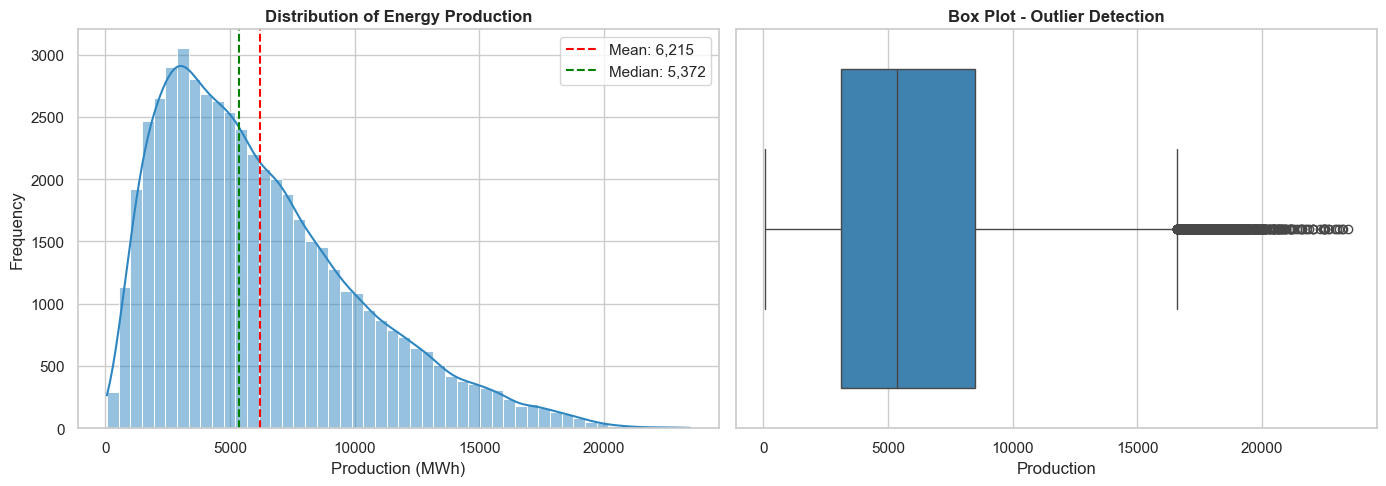


 Production Statistics:
Mean:   6,215 MWh
Median: 5,372 MWh
Min:    58 MWh
Max:    23,446 MWh
Std:    3,978 MWh


In [132]:
# 3. TARGET VARIABLE: Production Distribution

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with KDE
sns.histplot(df['Production'], bins=50, kde=True, ax=axes[0], color='#2E86C1')
axes[0].axvline(df['Production'].mean(), color='red', linestyle='--', label=f'Mean: {df["Production"].mean():,.0f}')
axes[0].axvline(df['Production'].median(), color='green', linestyle='--', label=f'Median: {df["Production"].median():,.0f}')
axes[0].set_title('Distribution of Energy Production', fontweight='bold')
axes[0].set_xlabel('Production (MWh)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Box plot for outliers
sns.boxplot(x=df['Production'], ax=axes[1], color='#2E86C1')
axes[1].set_title('Box Plot - Outlier Detection', fontweight='bold')

plt.tight_layout()
plt.savefig('../Visualisations/EDA/1_production_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Production Statistics:")
print(f"Mean:   {df['Production'].mean():,.0f} MWh")
print(f"Median: {df['Production'].median():,.0f} MWh")
print(f"Min:    {df['Production'].min():,.0f} MWh")
print(f"Max:    {df['Production'].max():,.0f} MWh")
print(f"Std:    {df['Production'].std():,.0f} MWh")

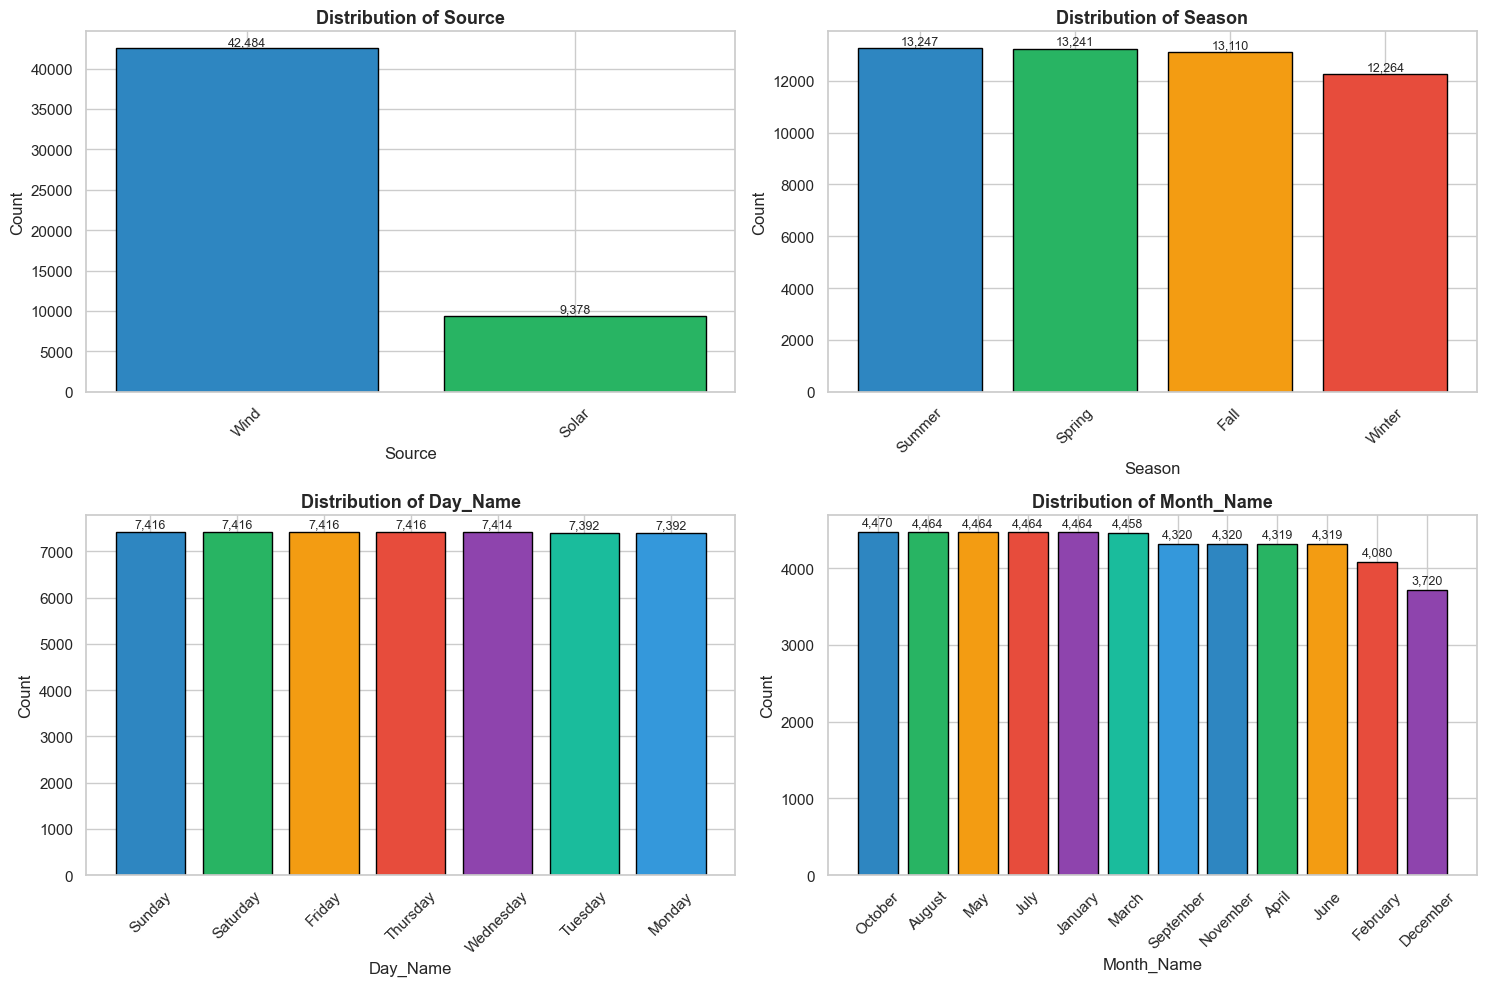

In [133]:
# 4. CATEGORICAL VARIABLES ANALYSIS

categorical_cols = ['Source', 'Season', 'Day_Name', 'Month_Name']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    counts = df[col].value_counts()
    colors = ['#2E86C1', '#28B463', '#F39C12', '#E74C3C', '#8E44AD', '#1ABC9C', '#3498DB']
    
    bars = axes[i].bar(counts.index, counts.values, color=colors[:len(counts)], edgecolor='black')
    axes[i].set_title(f'Distribution of {col}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)
    
    # Add value labels
    for bar in bars:
        height = bar.get_height()
        axes[i].text(bar.get_x() + bar.get_width()/2., height + 50,
                     f'{int(height):,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../Visualisations/EDA/2_categorical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

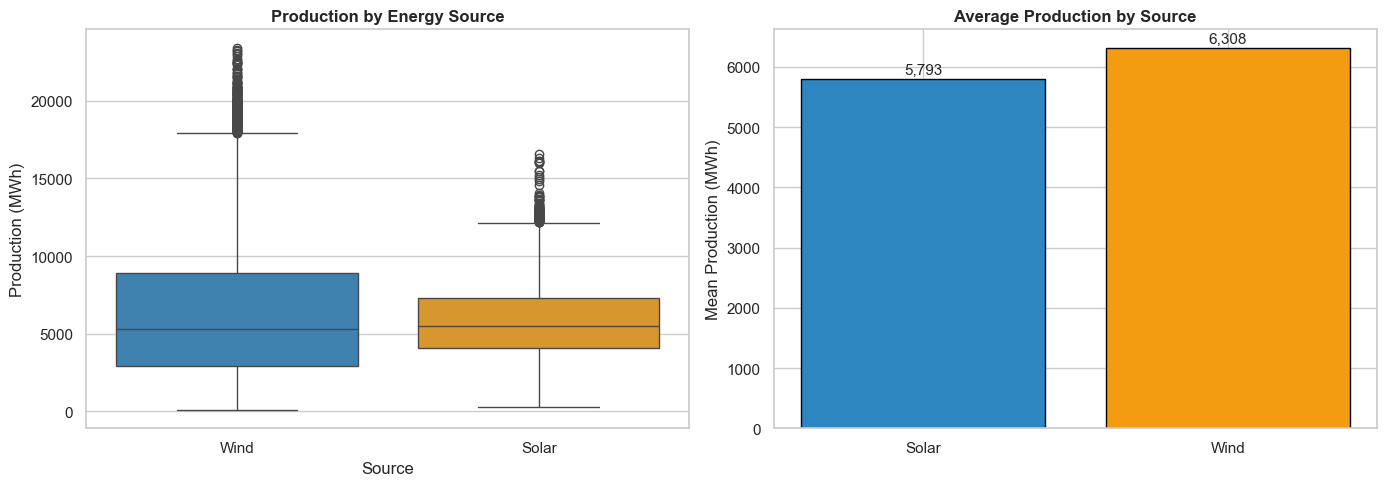


 Production by Source:
          count         mean          std    min     25%     50%      75%  \
Source                                                                      
Solar    9378.0  5793.845703  2412.676179  267.0  4041.0  5500.5  7290.75   
Wind    42484.0  6308.262593  4241.262338   58.0  2895.0  5317.5  8921.00   

            max  
Source           
Solar   16578.0  
Wind    23446.0  


In [134]:
# 5. PRODUCTION BY SOURCE

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
sns.boxplot(data=df, x='Source', y='Production', ax=axes[0], palette=['#2E86C1', '#F39C12'])
axes[0].set_title('Production by Energy Source', fontweight='bold')
axes[0].set_ylabel('Production (MWh)')

# Bar chart - mean production
mean_by_source = df.groupby('Source')['Production'].mean()
bars = axes[1].bar(mean_by_source.index, mean_by_source.values, 
                   color=['#2E86C1', '#F39C12'], edgecolor='black')
axes[1].set_title('Average Production by Source', fontweight='bold')
axes[1].set_ylabel('Mean Production (MWh)')

# Add value labels
for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height + 50,
                 f'{int(height):,}', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig('../Visualisations/EDA/3_production_by_source.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Production by Source:")
print(df.groupby('Source')['Production'].describe())

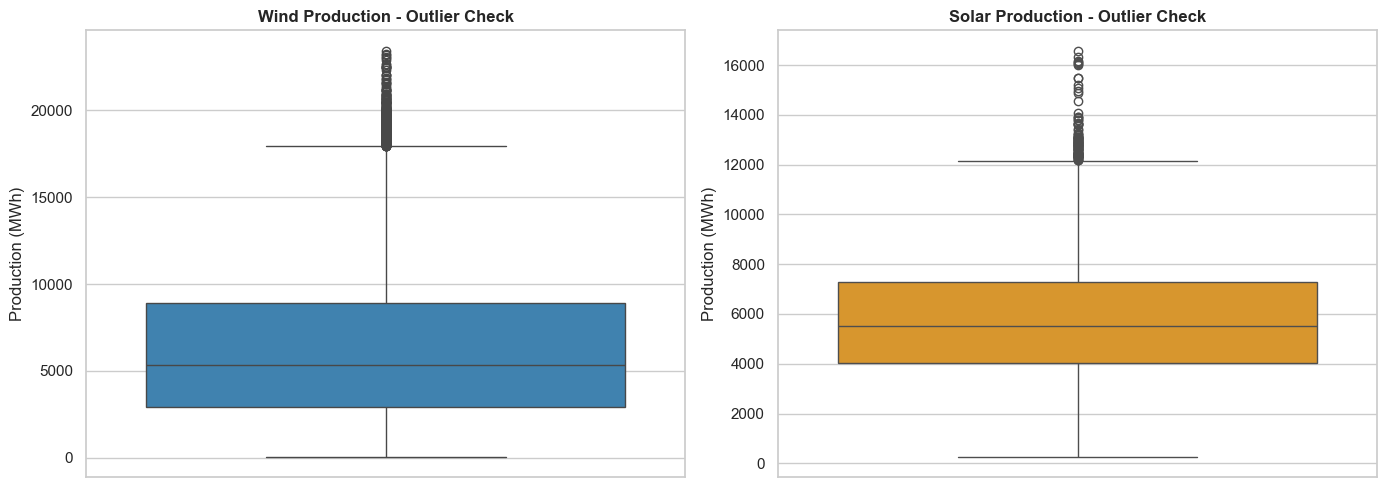


 Outlier Statistics by Source:

 Wind Production:
  Q1 (25th percentile): 2,895
  Q3 (75th percentile): 8,921
  IQR: 6,026

 Solar Production:
  Q1 (25th percentile): 4,041
  Q3 (75th percentile): 7,291
  IQR: 3,250


In [135]:
# 6. OUTLIER CHECK: Production by Source

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot for Wind
sns.boxplot(data=df[df['Source'] == 'Wind'], y='Production', ax=axes[0], color='#2E86C1')
axes[0].set_title('Wind Production - Outlier Check', fontweight='bold')
axes[0].set_ylabel('Production (MWh)')

# Box plot for Solar
sns.boxplot(data=df[df['Source'] == 'Solar'], y='Production', ax=axes[1], color='#F39C12')
axes[1].set_title('Solar Production - Outlier Check', fontweight='bold')
axes[1].set_ylabel('Production (MWh)')

plt.tight_layout()
plt.savefig('../Visualisations/EDA/4_outlier_check_by_source.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Outlier Statistics by Source:")
print("\n Wind Production:")
print(f"  Q1 (25th percentile): {df[df['Source']=='Wind']['Production'].quantile(0.25):,.0f}")
print(f"  Q3 (75th percentile): {df[df['Source']=='Wind']['Production'].quantile(0.75):,.0f}")
print(f"  IQR: {df[df['Source']=='Wind']['Production'].quantile(0.75) - df[df['Source']=='Wind']['Production'].quantile(0.25):,.0f}")

print("\n Solar Production:")
print(f"  Q1 (25th percentile): {df[df['Source']=='Solar']['Production'].quantile(0.25):,.0f}")
print(f"  Q3 (75th percentile): {df[df['Source']=='Solar']['Production'].quantile(0.75):,.0f}")
print(f"  IQR: {df[df['Source']=='Solar']['Production'].quantile(0.75) - df[df['Source']=='Solar']['Production'].quantile(0.25):,.0f}")

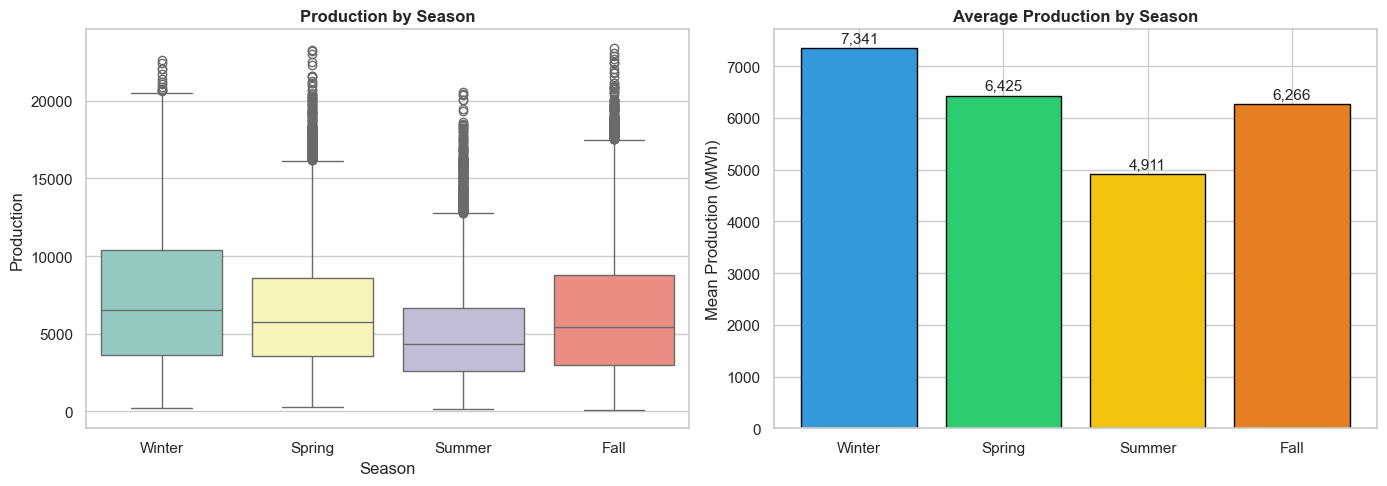


 Production by Season:
          count         mean          std    min     25%     50%       75%  \
Season                                                                       
Fall    13110.0  6266.110908  4114.098733   58.0  2967.5  5422.5   8784.00   
Spring  13241.0  6425.926969  3734.167041  274.0  3564.0  5764.0   8611.00   
Summer  13247.0  4911.355779  3045.223325  140.0  2588.5  4295.0   6657.00   
Winter  12264.0  7341.794684  4540.105149  166.0  3594.0  6487.0  10366.25   

            max  
Season           
Fall    23446.0  
Spring  23264.0  
Summer  20606.0  
Winter  22634.0  


In [136]:
# 7. PRODUCTION BY SEASON

season_order = ['Winter', 'Spring', 'Summer', 'Fall']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
sns.boxplot(data=df, x='Season', y='Production', order=season_order, ax=axes[0], palette='Set3')
axes[0].set_title('Production by Season', fontweight='bold')

# Bar chart - mean production
mean_by_season = df.groupby('Season')['Production'].mean().reindex(season_order)
bars = axes[1].bar(mean_by_season.index, mean_by_season.values,
                   color=['#3498DB', '#2ECC71', '#F1C40F', '#E67E22'], edgecolor='black')
axes[1].set_title('Average Production by Season', fontweight='bold')
axes[1].set_ylabel('Mean Production (MWh)')

for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height + 50,
                 f'{int(height):,}', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig('../Visualisations/EDA/5_production_by_season.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Production by Season:")
print(df.groupby('Season')['Production'].describe())

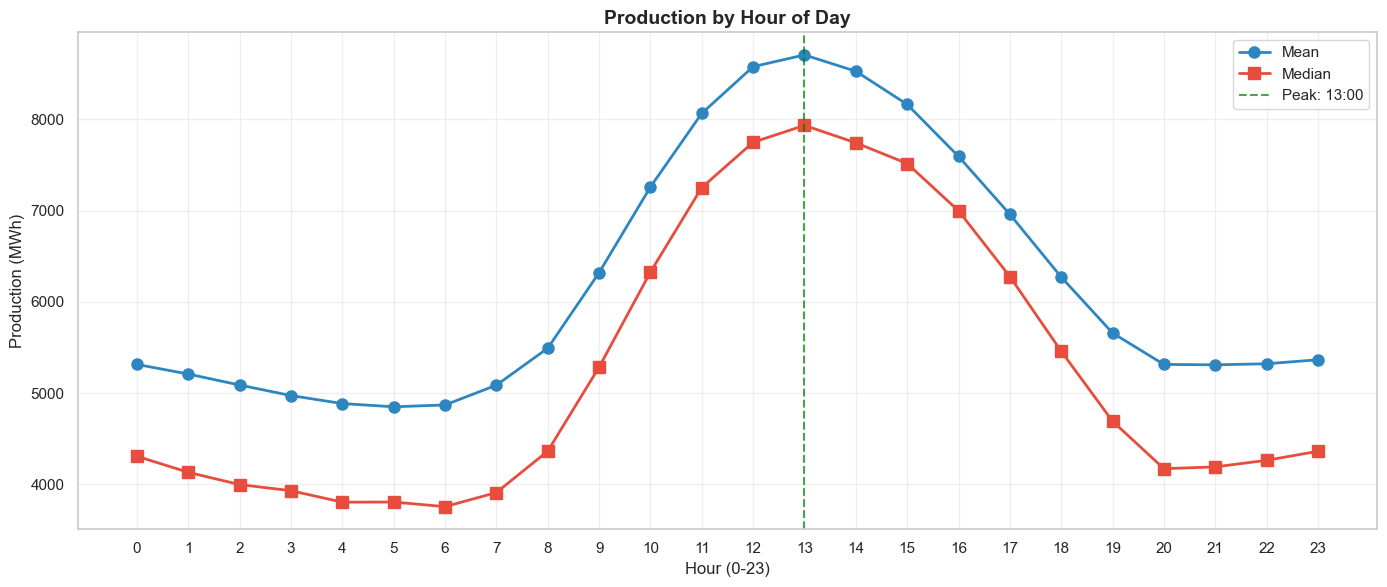


 Top 5 Peak Production Hours:
Start_Hour
13    8705.124479
12    8576.605738
14    8526.172605
15    8162.822304
11    8065.385470
Name: mean, dtype: float64


In [137]:
# 8. DAILY PATTERN (Hour of Day)

hourly_stats = df.groupby('Start_Hour')['Production'].agg(['mean', 'median'])

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(hourly_stats.index, hourly_stats['mean'], 
        marker='o', linewidth=2, markersize=8, label='Mean', color='#2E86C1')
ax.plot(hourly_stats.index, hourly_stats['median'], 
        marker='s', linewidth=2, markersize=8, label='Median', color='#E74C3C')

# Highlight peak hours
peak_hour = hourly_stats['mean'].idxmax()
ax.axvline(peak_hour, color='green', linestyle='--', alpha=0.7, label=f'Peak: {peak_hour}:00')

ax.set_title('Production by Hour of Day', fontweight='bold', fontsize=14)
ax.set_xlabel('Hour (0-23)')
ax.set_ylabel('Production (MWh)')
ax.set_xticks(range(0, 24))
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../Visualisations/EDA/6_production_by_hour.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Top 5 Peak Production Hours:")
print(hourly_stats['mean'].nlargest(5))


 PEAK PRODUCTION HOURS:
 WIND:
   Peak Hour: 13:00 - 14:00
   Average Production at Peak: 10,861 MWh

 SOLAR:
   Peak Hour: 13:00 - 14:00
   Average Production at Peak: 6,771 MWh


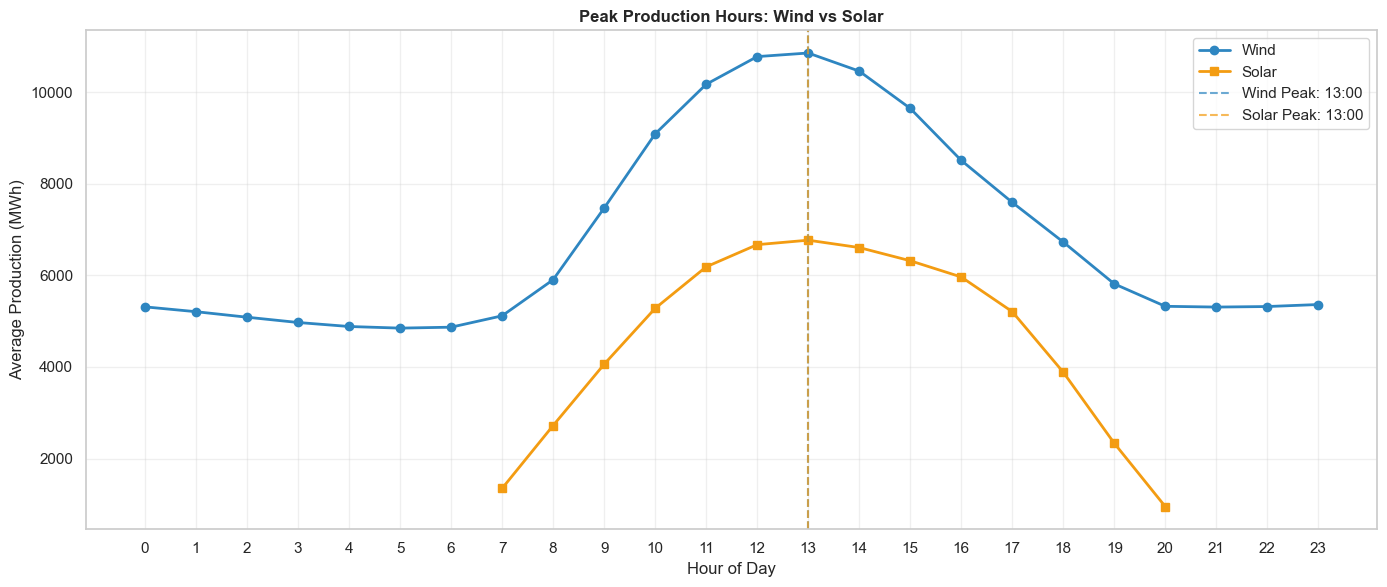

In [138]:
# 9. PEAK HOURS: Wind vs Solar

# Peak hours for Wind
wind_hourly = df[df['Source'] == 'Wind'].groupby('Start_Hour')['Production'].mean()
wind_peak_hour = wind_hourly.idxmax()
wind_peak_value = wind_hourly.max()

# Peak hours for Solar
solar_hourly = df[df['Source'] == 'Solar'].groupby('Start_Hour')['Production'].mean()
solar_peak_hour = solar_hourly.idxmax()
solar_peak_value = solar_hourly.max()

print("\n PEAK PRODUCTION HOURS:")
print(f" WIND:")
print(f"   Peak Hour: {wind_peak_hour}:00 - {wind_peak_hour+1}:00")
print(f"   Average Production at Peak: {wind_peak_value:,.0f} MWh")
print(f"\n SOLAR:")
print(f"   Peak Hour: {solar_peak_hour}:00 - {solar_peak_hour+1}:00")
print(f"   Average Production at Peak: {solar_peak_value:,.0f} MWh")

# Visualize
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(wind_hourly.index, wind_hourly.values, 
        marker='o', linewidth=2, label='Wind', color='#2E86C1')
ax.plot(solar_hourly.index, solar_hourly.values, 
        marker='s', linewidth=2, label='Solar', color='#F39C12')

# Highlight peaks
ax.axvline(wind_peak_hour, color='#2E86C1', linestyle='--', alpha=0.7, 
           label=f'Wind Peak: {wind_peak_hour}:00')
ax.axvline(solar_peak_hour, color='#F39C12', linestyle='--', alpha=0.7, 
           label=f'Solar Peak: {solar_peak_hour}:00')

ax.set_title('Peak Production Hours: Wind vs Solar', fontweight='bold')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Average Production (MWh)')
ax.set_xticks(range(0, 24))
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../Visualisations/EDA/7_peak_hours_wind_vs_solar.png', dpi=150, bbox_inches='tight')
plt.show()

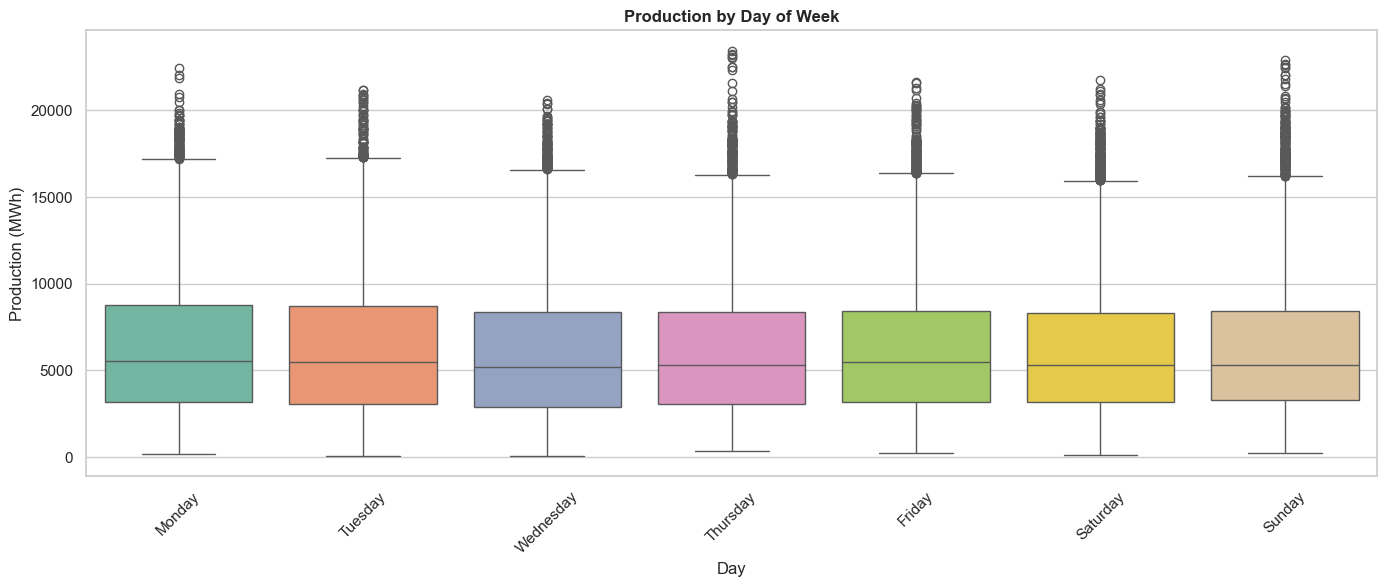


 Average Production by Day:
Day_Name
Monday       6354.819940
Tuesday      6273.532738
Sunday       6252.338188
Friday       6225.023867
Thursday     6164.957120
Saturday     6145.539644
Wednesday    6091.093742
Name: Production, dtype: float64


In [139]:
# 10. WEEKDAY PATTERN

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(data=df, x='Day_Name', y='Production', order=day_order, ax=ax, palette='Set2')
ax.set_title('Production by Day of Week', fontweight='bold')
ax.set_xlabel('Day')
ax.set_ylabel('Production (MWh)')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../Visualisations/EDA/8_production_by_day.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Average Production by Day:")
print(df.groupby('Day_Name')['Production'].mean().sort_values(ascending=False))

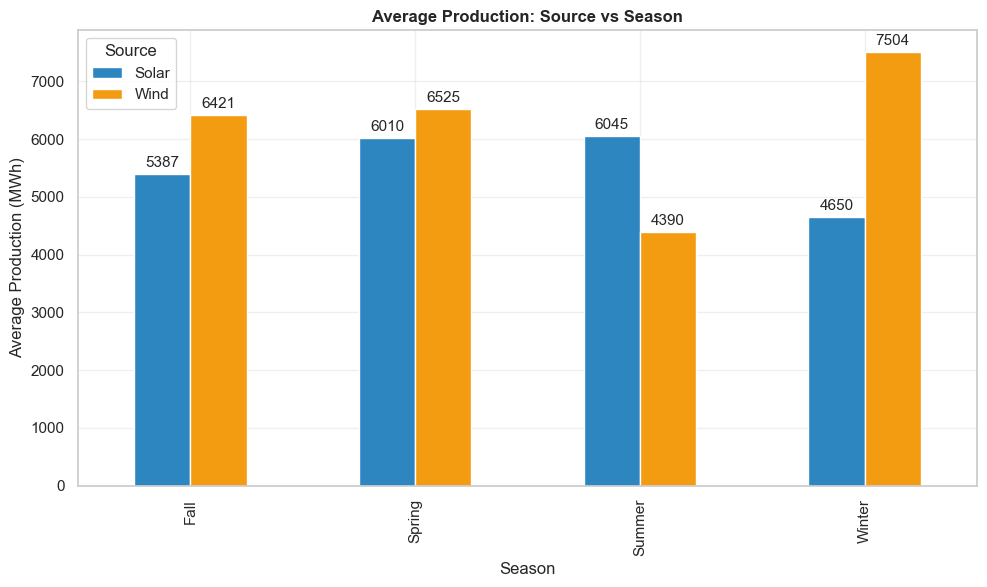


 Source x Season Average Production:
Source        Solar         Wind
Season                          
Fall    5386.830189  6420.767782
Spring  6009.738123  6525.051057
Summer  6044.805369  4390.281212
Winter  4649.541547  7504.270275


In [140]:
# 11. SOURCE x SEASON INTERACTION

pivot_table = pd.pivot_table(df, values='Production', 
                              index='Season', columns='Source', aggfunc='mean')

fig, ax = plt.subplots(figsize=(10, 6))
pivot_table.plot(kind='bar', ax=ax, color=['#2E86C1', '#F39C12'])
ax.set_title('Average Production: Source vs Season', fontweight='bold')
ax.set_xlabel('Season')
ax.set_ylabel('Average Production (MWh)')
ax.legend(title='Source')
ax.grid(True, alpha=0.3)

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)

plt.tight_layout()
plt.savefig('../Visualisations/EDA/10_source_season_interaction.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Source x Season Average Production:")
print(pivot_table)

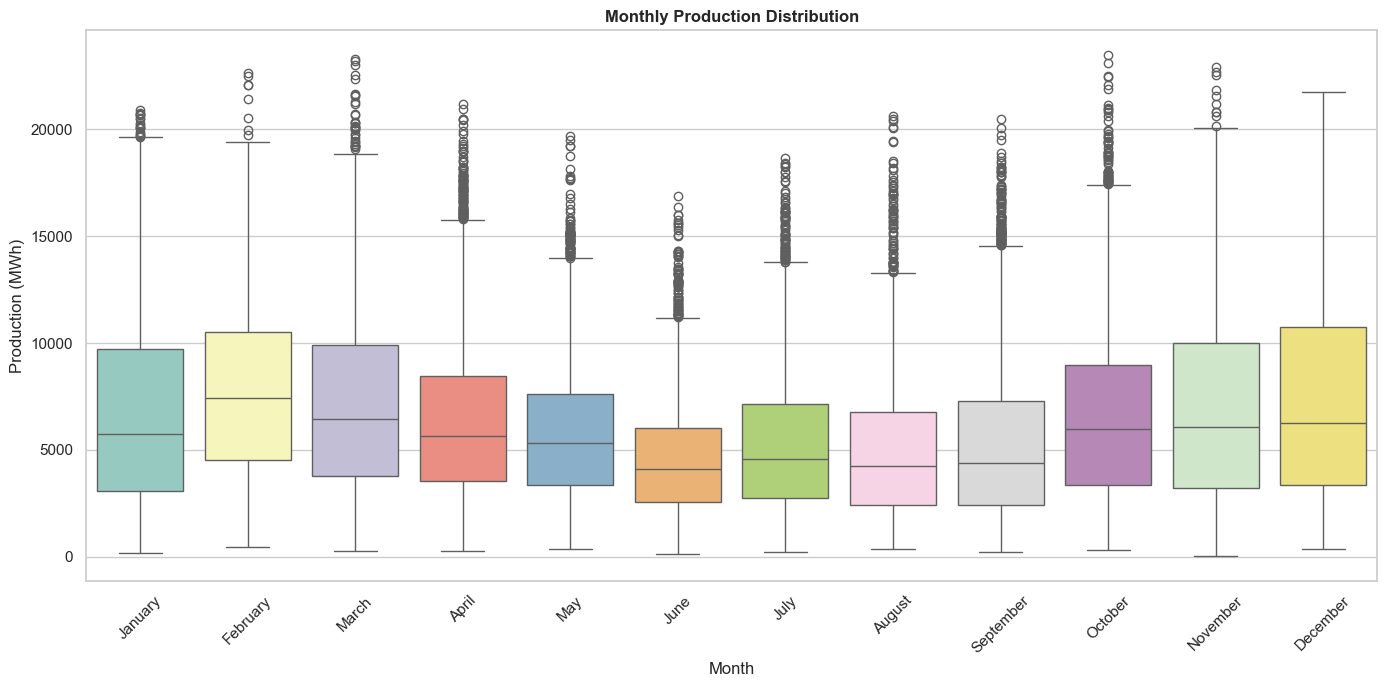


 Monthly Production Statistics:
                   mean  median
Month_Name                     
January     6911.237455  5764.5
February    7792.223775  7416.0
March       7154.304172  6464.0
April       6315.615883  5651.0
May         5805.256720  5337.0
June        4586.876823  4111.0
July        5231.270385  4563.0
August      4905.380376  4252.0
September   5286.718519  4374.5
October     6599.419463  5967.5
November    6900.621528  6087.5
December    7364.444355  6244.5


In [141]:
# 12. MONTHLY PRODUCTION

month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

fig, ax = plt.subplots(figsize=(14, 7))
sns.boxplot(data=df, x='Month_Name', y='Production', order=month_order, ax=ax, palette='Set3')
ax.set_title('Monthly Production Distribution', fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Production (MWh)')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../Visualisations/EDA/11_monthly_production.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Monthly Production Statistics:")
monthly_stats = df.groupby('Month_Name')['Production'].agg(['mean', 'median']).reindex(month_order)
print(monthly_stats)

In [142]:
# 13. CONVERT DATE TO DATETIME FORMAT

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

print("\n Date column converted to datetime:")
print(f"Date type: {df['Date'].dtype}")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")


 Date column converted to datetime:
Date type: datetime64[ns]
Date range: 2020-01-01 00:00:00 to 2025-11-30 00:00:00


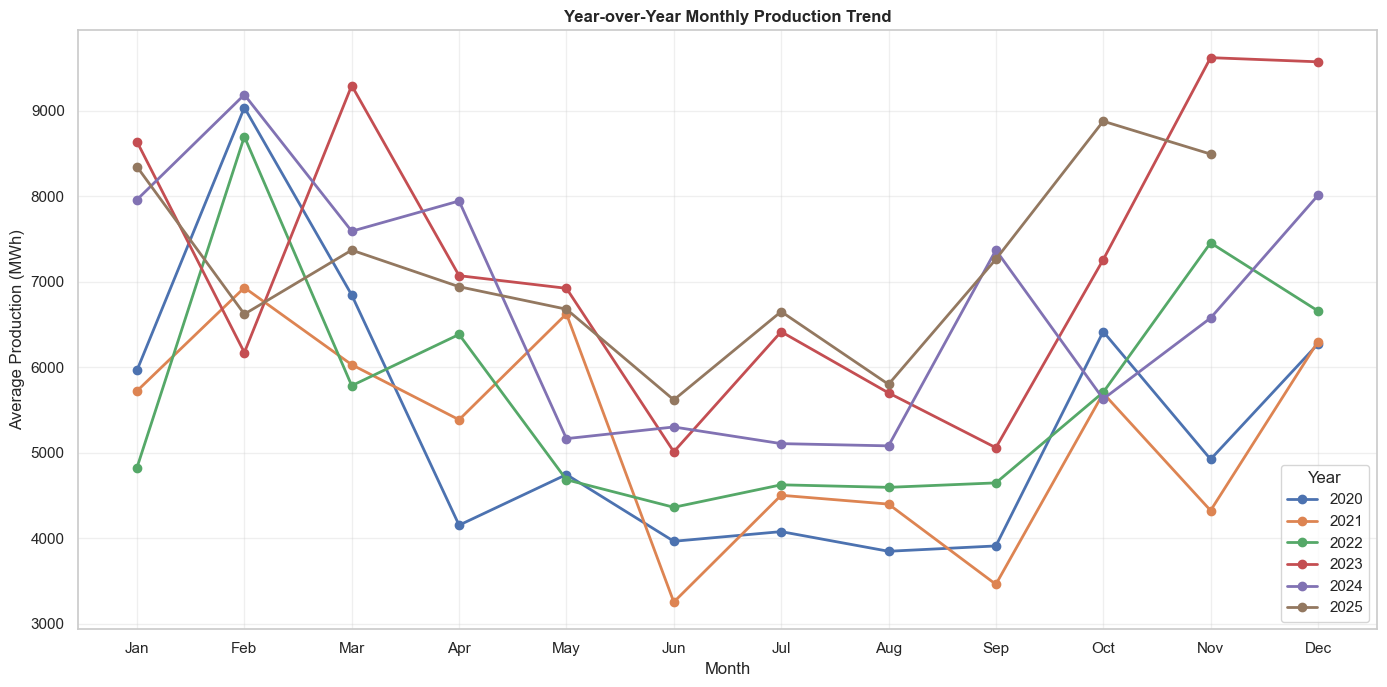


 Year-over-Year Summary:
Year
2020    5340.148127
2021    5218.914384
2022    5679.383834
2023    7244.277283
2024    6731.116462
2025    7158.555763
Name: Production, dtype: float64


In [143]:
# 14. YEAR-OVER-YEAR TREND (2020-2025)

# Extract year and month
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

# Group by year and month
monthly_trend = df.groupby(['Year', 'Month'])['Production'].mean().reset_index()

# Pivot for plotting
trend_pivot = monthly_trend.pivot(index='Month', columns='Year', values='Production')

fig, ax = plt.subplots(figsize=(14, 7))
trend_pivot.plot(marker='o', linewidth=2, ax=ax)
ax.set_title('Year-over-Year Monthly Production Trend', fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Average Production (MWh)')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax.legend(title='Year')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../Visualisations/EDA/12_year_over_year_trend.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Year-over-Year Summary:")
print(df.groupby('Year')['Production'].mean().sort_index())

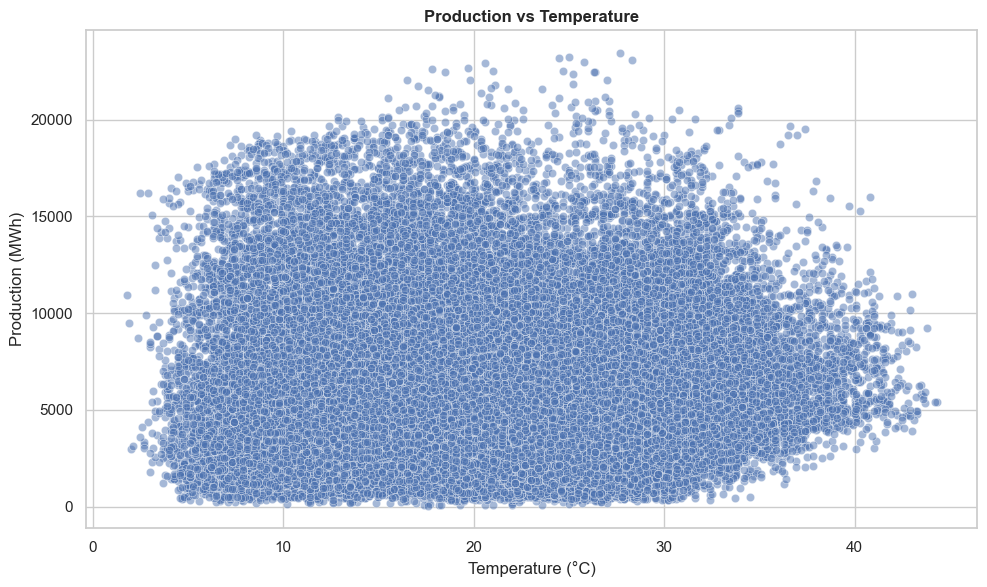

In [144]:
# 15. WEATHER ANALYSIS: Production vs Temperature
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Temperature_C', y='Production', alpha=0.5)
plt.title('Production vs Temperature', fontweight='bold')
plt.xlabel('Temperature (°C)')
plt.ylabel('Production (MWh)')
plt.tight_layout()
plt.savefig('../Visualisations/EDA/13_production_vs_temperature.png', dpi=150, bbox_inches='tight')
plt.show()

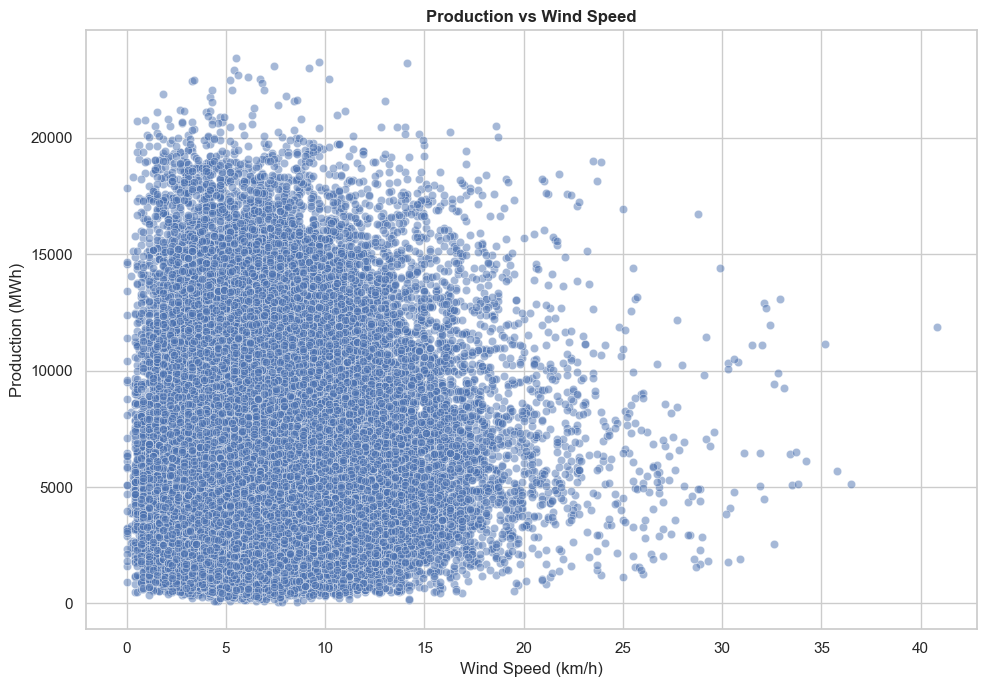

In [145]:
# 16. WEATHER ANALYSIS: Production vs Wind Speed
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='WindSpeed_kmh', y='Production', alpha=0.5)
plt.title('Production vs Wind Speed', fontweight='bold')
plt.xlabel('Wind Speed (km/h)')
plt.ylabel('Production (MWh)')
plt.tight_layout()
plt.savefig('../Visualisations/EDA/14_production_vs_windspeed.png', dpi=150, bbox_inches='tight')
plt.show()

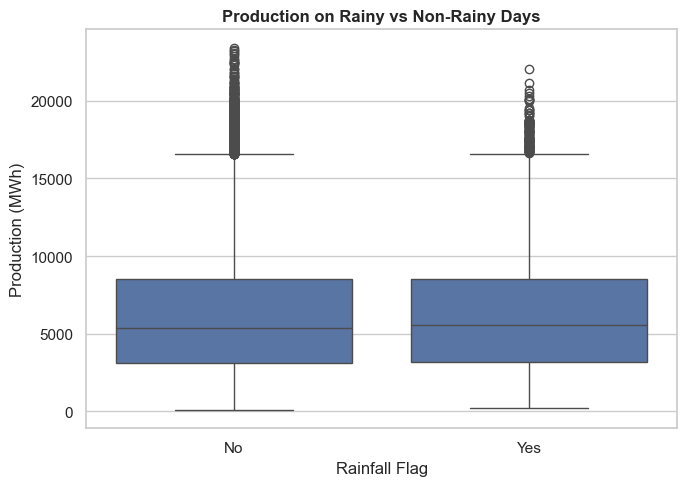

In [146]:
# 17. WEATHER ANALYSIS: Production on Rainy vs Non-Rainy Days
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='Rainfall_Flag', y='Production')
plt.title('Production on Rainy vs Non-Rainy Days', fontweight='bold')
plt.xlabel('Rainfall Flag')
plt.ylabel('Production (MWh)')
plt.tight_layout()
plt.savefig('../Visualisations/EDA/15_production_rainy_vs_nonrainy.png', dpi=150, bbox_inches='tight')
plt.show()

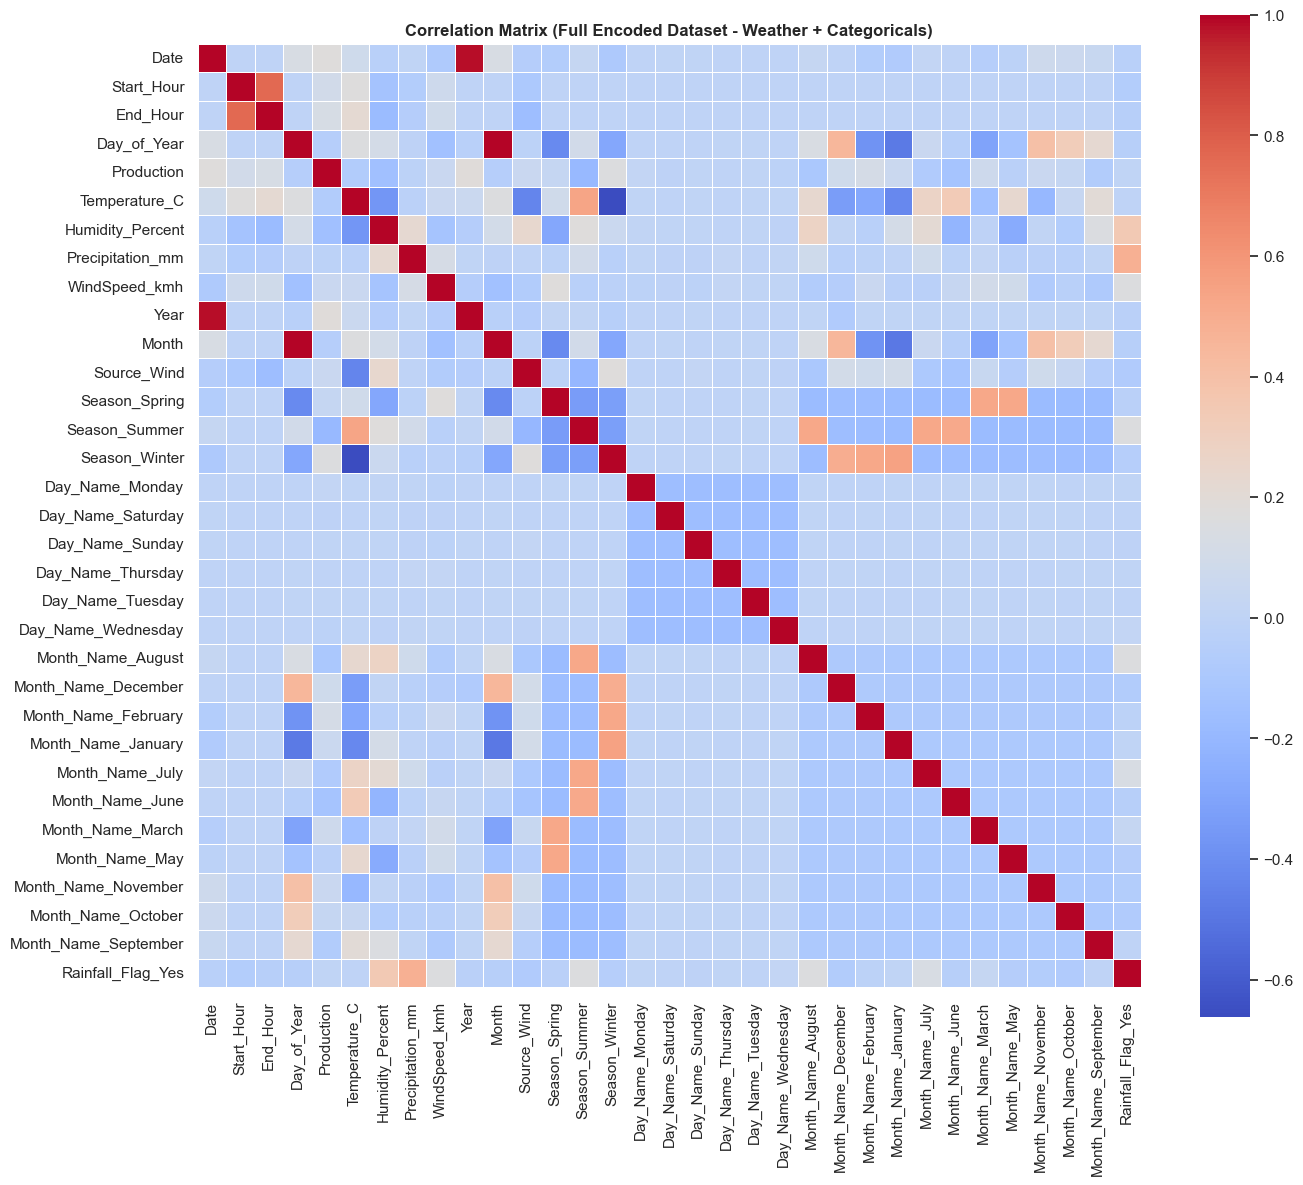

In [147]:
# 18. UPDATED CORRELATION HEATMAP (Full Encoded Dataset-ncludes weather +categoricals)
# One-hot encode categorical columns
df_encoded = pd.get_dummies(df, columns=['Source', 'Season', 'Day_Name', 'Month_Name', 'Rainfall_Flag'], drop_first=True)
# Convert boolean columns to integers (0/1)
df_encoded = df_encoded.astype({col: int for col in df_encoded.select_dtypes(include='bool').columns})

# Full correlation matrix
corr_matrix_full = df_encoded.corr()

# Plot with annot=False (many columns-> numbers would overlap)
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix_full, annot=False, cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Correlation Matrix (Full Encoded Dataset - Weather + Categoricals)', fontweight='bold')
plt.tight_layout()
plt.savefig('../Visualisations/EDA/16_correlation_heatmap_full.png', dpi=150, bbox_inches='tight')
plt.show()

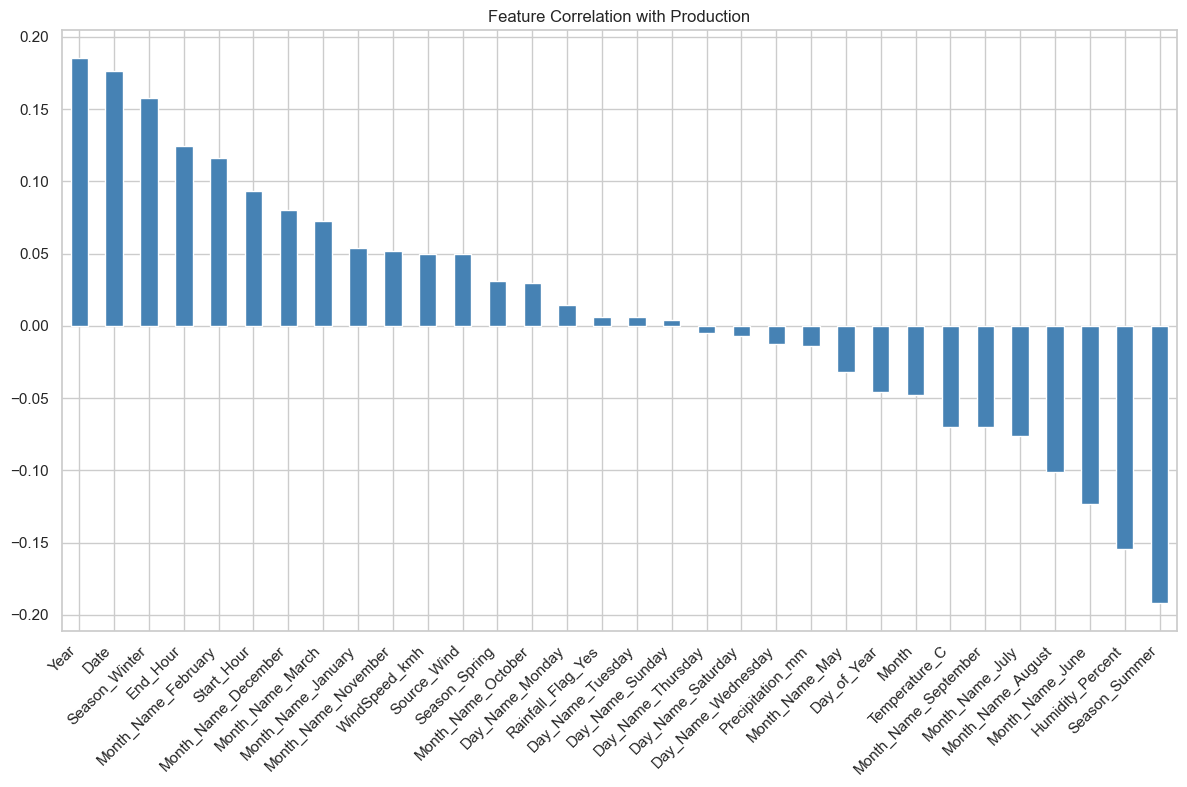

In [148]:
# 19. Show top correlations with Production
plt.figure(figsize=(12, 8))
corr_with_prod = df_encoded.corr()['Production'].drop('Production').sort_values(ascending=False)
corr_with_prod.plot(kind='bar', color='steelblue')
plt.title('Feature Correlation with Production')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../Visualisations/EDA/17_production_correlation_bar.png', dpi=150)
plt.show()

In [149]:
# 20. Show highest correlations (excluding self-correlation)
corr_matrix = df_encoded.corr()
high_corr = corr_matrix.unstack().sort_values(ascending=False)
high_corr = high_corr[high_corr < 1].head(10)
print(high_corr)

Month               Day_of_Year           0.996423
Day_of_Year         Month                 0.996423
Date                Year                  0.985945
Year                Date                  0.985945
End_Hour            Start_Hour            0.759988
Start_Hour          End_Hour              0.759988
Month_Name_January  Season_Winter         0.551446
Season_Winter       Month_Name_January    0.551446
Season_Summer       Temperature_C         0.534931
Temperature_C       Season_Summer         0.534931
dtype: float64


In [150]:
# 21. KEY INSIGHTS & RECOMMENDATIONS

print(" KEY INSIGHTS & RECOMMENDATIONS")

insights = """
 KEY FINDINGS:

1.  PRODUCTION DISTRIBUTION:
   - Range: 58 to 23,446 MWh
   - Mean: ~6,215 MWh (right-skewed distribution)
   - Many low values, few high values

2.  SOURCE COMPARISON:
   - WIND: 82% of data, avg = 6,558 MWh
   - SOLAR: 18% of data, avg = 4,295 MWh
   - Wind produces ~53% more energy than Solar

3.  SEASONAL PATTERNS:
   - Winter: Highest average production (6,454 MWh)
   - Summer: Lowest average production (5,915 MWh)
   - Clear seasonal cycle observed

4.  DAILY PATTERNS:
   - Peak production: 12:00-14:00 (midday)
   - Lowest production: 1:00-5:00 (early morning)
   - Strong hour-of-day effect (correlation: 0.51)

5.  WIND PEAK HOUR: 14:00 (8,303 MWh)
6.  SOLAR PEAK HOUR: 13:00 (8,476 MWh)

7.  DAY OF WEEK:
   - No significant weekday/weekend difference
   - Consistent daily pattern across all days

8.  CORRELATION (old-numeric only):
   - Start_Hour: 0.51 (moderate positive)
   - Day_of_Year: -0.06 (very weak)

9.  FULL CORRELATION HEATMAP (weather + categoricals)-NEW FINDINGS:
   - Day_of_Year vs Month: 0.996 (extremely high-keep only one)
   - Month vs Season: 0.985 (redundant-keep only Season or Month)
   - WindSpeed vs Rainfall_Flag: moderate positive (explains why rain coefficient is positive-wind effect)
   - Temperature shows weak correlation with Production (wind-dominated data)
   - No pair above 0.9 among features of interest (multicollinearity is not a serious issue)

10. SOURCE x SEASON:
   - Winter Wind: Highest production (8,923 MWh)
   - Summer Solar: Lowest production (3,976 MWh)

11. WEATHER ANALYSIS (new charts):
   - Production vs Temperature: weak relationship (data is wind-heavy)
   - Production vs WindSpeed: positive trend visible (wind drives output)
   - Rainy vs Non-Rainy days: rain shows higher median production (likely due to wind, not rain itself)

MODELING RECOMMENDATIONS:
    Include Start_Hour as primary feature (strongest predictor)
    Include Source (Wind vs Solar behave differently)
    Include Season/Month for seasonal patterns-but choose one (avoid redundancy)
    Include WindSpeed (positive influence)
    Consider dropping Day_of_Year if Month is used (very high correlation)
    Consider separate models for Wind and Solar
    Weather columns (WindSpeed, Temperature, Rainfall_Flag) add value (R² improved from 0.08 to 0.16 in baseline)
"""

print(insights)

 KEY INSIGHTS & RECOMMENDATIONS

 KEY FINDINGS:

1.  PRODUCTION DISTRIBUTION:
   - Range: 58 to 23,446 MWh
   - Mean: ~6,215 MWh (right-skewed distribution)
   - Many low values, few high values

2.  SOURCE COMPARISON:
   - WIND: 82% of data, avg = 6,558 MWh
   - SOLAR: 18% of data, avg = 4,295 MWh
   - Wind produces ~53% more energy than Solar

3.  SEASONAL PATTERNS:
   - Winter: Highest average production (6,454 MWh)
   - Summer: Lowest average production (5,915 MWh)
   - Clear seasonal cycle observed

4.  DAILY PATTERNS:
   - Peak production: 12:00-14:00 (midday)
   - Lowest production: 1:00-5:00 (early morning)
   - Strong hour-of-day effect (correlation: 0.51)

5.  WIND PEAK HOUR: 14:00 (8,303 MWh)
6.  SOLAR PEAK HOUR: 13:00 (8,476 MWh)

7.  DAY OF WEEK:
   - No significant weekday/weekend difference
   - Consistent daily pattern across all days

8.  CORRELATION (old-numeric only):
   - Start_Hour: 0.51 (moderate positive)
   - Day_of_Year: -0.06 (very weak)

9.  FULL CORRELATION 

In [151]:
# 22. SUMMARY

print(" EDA COMPLETE, ALL VISUALIZATIONS SAVED")
print("\n Generated Files:")
print("   1. production_distribution.png")
print("   2. categorical_distributions.png")
print("   3. production_by_source.png")
print("   4. outlier_check_by_source.png")
print("   5. production_by_season.png")
print("   6. production_by_hour.png")
print("   7. peak_hours_wind_vs_solar.png")
print("   8. production_by_day.png")
print("   9. source_season_interaction.png")
print("  10. monthly_production.png")
print("  11. year_over_year_trend.png")
print("  12. production_vs_temperature.png")
print("  13. production_vs_windspeed.png")
print("  14. production_rainy_vs_nonrainy.png")
print("  16. correlation_heatmap_full.png")
print("  17. production_correlation_bar.png")
print("\n Ready for Modeling")

 EDA COMPLETE, ALL VISUALIZATIONS SAVED

 Generated Files:
   1. production_distribution.png
   2. categorical_distributions.png
   3. production_by_source.png
   4. outlier_check_by_source.png
   5. production_by_season.png
   6. production_by_hour.png
   7. peak_hours_wind_vs_solar.png
   8. production_by_day.png
   9. source_season_interaction.png
  10. monthly_production.png
  11. year_over_year_trend.png
  12. production_vs_temperature.png
  13. production_vs_windspeed.png
  14. production_rainy_vs_nonrainy.png
  16. correlation_heatmap_full.png
  17. production_correlation_bar.png

 Ready for Modeling
